In [517]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
import tensorflow.keras as keras
import keras.layers as layers
import keras.models as models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from wordcloud import WordCloud

from nltk.tokenize import TweetTokenizer # TweetTokenizer handles apostrophes and contractions better than word_tokenize for our use case
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.corpus import stopwords

In [491]:
# configure pandas ouput to show all columns and full text
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [492]:
# Load Dataset
data = pd.read_csv('EN_FR_data.tsv', sep='\t')
data.columns = ['EN_Sent_ID','English', 'FR_Sent_ID','French']

In [493]:
# reduce data size to 10000 rows for feasibility of training
data = data.head(10000)

In [494]:
data

,EN_Sent_ID,English,FR_Sent_ID,French
0,1276,Let's try something.,456963,Tentons quelque chose !
1,1277,I have to go to sleep.,373908,Je dois aller dormir.
2,1280,Today is June 18th and it is Muiriel's birthday!,3095,Aujourd'hui nous sommes le 18 juin et c'est l'anniversaire de Muiriel !
3,1280,Today is June 18th and it is Muiriel's birthday!,696081,"Aujourd'hui c'est le 18 juin, et c'est l'anniversaire de Muiriel."
4,1282,Muiriel is 20 now.,3097,Muiriel a 20 ans maintenant.
...,...,...,...,...
9995,31364,It is time you left off your childish ways.,334821,Il est temps que tu abandonnes tes manières puériles.
9996,31365,It's high time the children went to bed.,8134,Il est grand temps que les enfants aillent dormir.
9997,31365,It's high time the children went to bed.,13609,Il est grand temps que les enfants aillent au lit.
9998,31366,I've already finished my work.,13608,J'ai déjà fini mon travail.


In [495]:
# preprocess text function
# perform lowercasing and remove punctuation that is not part of a word
def preprocess(text):
    pre_text = [word for word in TweetTokenizer().tokenize(text.lower()) if word.isalpha() or len(word) > 1]
    return " ".join(pre_text)

In [496]:
# Apply preprocessing to both English and French columns and save to new dataframe
df_clean = data.copy()
df_clean['English'] = df_clean['English'].apply(preprocess)
df_clean['French'] = df_clean['French'].apply(preprocess)

In [497]:
df_clean

,EN_Sent_ID,English,FR_Sent_ID,French
0,1276,let's try something,456963,tentons quelque chose
1,1277,i have to go to sleep,373908,je dois aller dormir
2,1280,today is june 18th and it is muiriel's birthday,3095,aujourd'hui nous sommes le 18 juin et c'est l'anniversaire de muiriel
3,1280,today is june 18th and it is muiriel's birthday,696081,aujourd'hui c'est le 18 juin et c'est l'anniversaire de muiriel
4,1282,muiriel is 20 now,3097,muiriel a 20 ans maintenant
...,...,...,...,...
9995,31364,it is time you left off your childish ways,334821,il est temps que tu abandonnes tes manières puériles
9996,31365,it's high time the children went to bed,8134,il est grand temps que les enfants aillent dormir
9997,31365,it's high time the children went to bed,13609,il est grand temps que les enfants aillent au lit
9998,31366,i've already finished my work,13608,j'ai déjà fini mon travail


In [498]:
# save cleaned data to new csv file
df_clean.to_csv("cleaned_data.csv", index=False, encoding='utf-8-sig')

Text(0.5, 1.0, 'French Word Cloud')

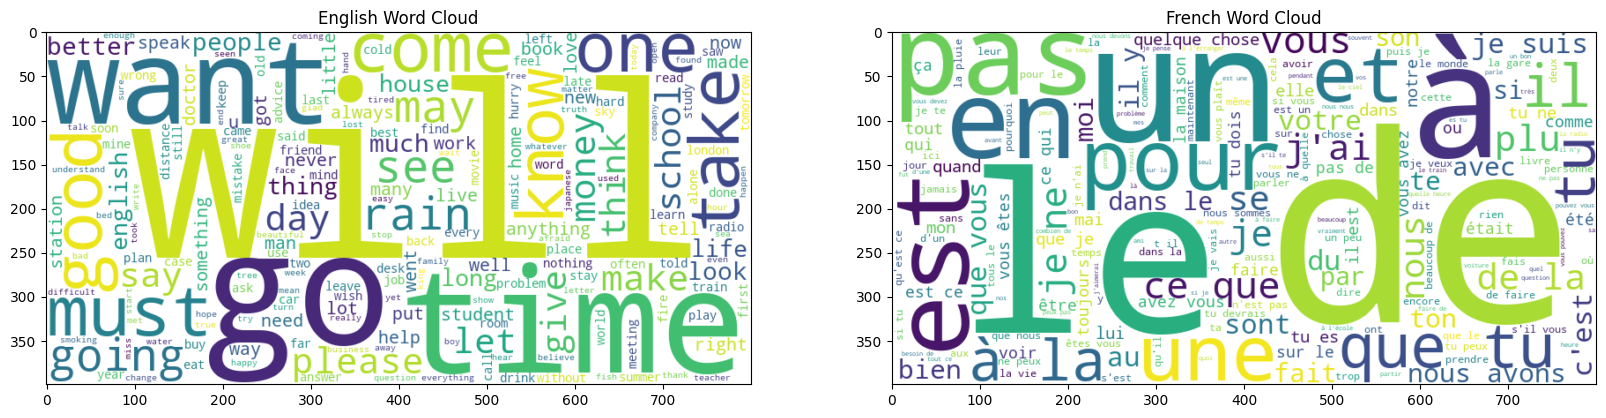

In [499]:
# visualize word frequency using wordclouds
english_text = " ".join(df_clean['English'])
french_text = " ".join(df_clean['French'])

english_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(english_text)
french_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(french_text)

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(english_wordcloud, interpolation='bilinear')
plt.title('English Word Cloud')

plt.subplot(1, 2, 2)
plt.imshow(french_wordcloud, interpolation='bilinear')
plt.title('French Word Cloud')

In [500]:
# convert dataframe to suitable format for training
# english and french sentences under one column with class labels
df_en = pd.DataFrame({
    "text": df_clean["English"],
    "label": "EN"
})

df_fr = pd.DataFrame({
    "text": df_clean["French"],
    "label": "FR"
})

df_train = pd.concat([df_en, df_fr]).sample(frac=1).reset_index(drop=True)

In [501]:
df_train

,text,label
0,judging from what you say he must be a great scholar,EN
1,it is never too late to learn,EN
2,vous devez terminer le travail avant l'échéance,FR
3,what would you do in my place,EN
4,il y a beaucoup d'argent,FR
...,...,...
19995,i'm glad we didn't go there because there were some localized heavy rain showers,EN
19996,the pirates had no choice but to surrender,EN
19997,why don't you eat vegetables,EN
19998,once gone you will never get it back,EN


In [502]:
# define x and y for training
x= df_train['text']
y = df_train['label']

In [503]:
# define function to convert sentence labels to token labels for token-level classification (needed for multilabel token classification)
def sentence_to_token_labels(sentences, labels):
    x_tokens = []
    y_tokens = []

    for sent, label in zip(sentences, labels):
        # white space split is enough as text is already preprocessed
        words = sent.split()

        x_tokens.append(words)
        y_tokens.append([label] * len(words))  # repeat sentence label for each token in the sentence (convert to word/token level labels)

    return x_tokens, y_tokens

In [504]:
# use function to get token-level labels for training
x_tokens, y_tokens = sentence_to_token_labels(x, y)

In [505]:
df_train["x_tokens"] = x_tokens
df_train["y_tokens"] = y_tokens
df_train

,text,label,x_tokens,y_tokens
0,judging from what you say he must be a great scholar,EN,"[judging, from, what, you, say, he, must, be, a, great, scholar]","[EN, EN, EN, EN, EN, EN, EN, EN, EN, EN, EN]"
1,it is never too late to learn,EN,"[it, is, never, too, late, to, learn]","[EN, EN, EN, EN, EN, EN, EN]"
2,vous devez terminer le travail avant l'échéance,FR,"[vous, devez, terminer, le, travail, avant, l'échéance]","[FR, FR, FR, FR, FR, FR, FR]"
3,what would you do in my place,EN,"[what, would, you, do, in, my, place]","[EN, EN, EN, EN, EN, EN, EN]"
4,il y a beaucoup d'argent,FR,"[il, y, a, beaucoup, d'argent]","[FR, FR, FR, FR, FR]"
...,...,...,...,...
19995,i'm glad we didn't go there because there were some localized heavy rain showers,EN,"[i'm, glad, we, didn't, go, there, because, there, were, some, localized, heavy, rain, showers]","[EN, EN, EN, EN, EN, EN, EN, EN, EN, EN, EN, EN, EN, EN]"
19996,the pirates had no choice but to surrender,EN,"[the, pirates, had, no, choice, but, to, surrender]","[EN, EN, EN, EN, EN, EN, EN, EN]"
19997,why don't you eat vegetables,EN,"[why, don't, you, eat, vegetables]","[EN, EN, EN, EN, EN]"
19998,once gone you will never get it back,EN,"[once, gone, you, will, never, get, it, back]","[EN, EN, EN, EN, EN, EN, EN, EN]"


In [506]:
# save training data to new csv file
df_train.drop(['text', 'label'], axis=1).to_csv("training_data.csv", index=False, encoding='utf-8-sig')

In [507]:
# get max sentence length stats to help determine max_len for padding
lengths = df_train["x_tokens"].apply(len)

print("Max length:", lengths.max())
print("Min length:", lengths.min())
print("Mean length:", lengths.mean())
print("Median length:", lengths.median())
print("95 percentile length:", lengths.quantile(0.95))

Max length: 69
Min length: 1
Mean length: 7.50995
Median length: 7.0
95 percentile length: 14.0


In [508]:
Q1 = lengths.quantile(0.25)
Q3 = lengths.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -1.0
Upper bound: 15.0


In [509]:
outliers = df_train[(lengths < lower_bound) | (lengths > upper_bound)]

print("Number of outlier sentences:", len(outliers))
outliers[["x_tokens"]].head()

Number of outlier sentences: 589


,x_tokens
23,"[peter, était, un, joueur, de, jeux, vidéo, altruiste, il, donnait, des, objets, aux, gens, qui, en, avaient, besoin, plutôt, que, de, les, vendre, par, intérêt, personnel]"
45,"[cole's, axiom, the, sum, of, the, intelligence, on, the, planet, is, a, constant, the, population, is, growing]"
87,"[dans, les, années, 50, on, citait, les, finnois, comme, ayant, les, régimes, alimentaires, les, moins, sains, du, monde]"
143,"[le, chef, de, la, guilde, relégua, vince, à, une, position, de, sous-officier, parce, qu'il, abusait, de, son, pouvoir]"
177,"[de, nos, jours, dans, les, affaires, trop, des, cadres, dépensent, de, l'argent, qu'ils, n'ont, pas, gagné, pour, acheter, des, choses, dont, ils, n'ont, pas, besoin, pour, impressionner, des, gens, qu'ils, n'aiment, même, pas]"


In [510]:
# define max sentence length as 95 percentile since outliers are present with much higher lengths than the rest of the data
max_len = int(lengths.quantile(0.95))
max_len

14

In [ ]:
# apply label encoding to class labels using manual labels
labels = {
    "PAD": 0,
    "EN": 1,
    "FR": 2
}

def encode_labels(label_sequences):
    # for each sequence of language tags, convert each tag to its corresponding integer label using the labels dictionary
    # then pad the sentences to ensure uniform length
    encoded = [[labels[tag] for tag in seq] for seq in label_sequences]
    return pad_sequences(encoded, maxlen=max_len, padding='post')

y_enc = encode_labels(y_tokens)

In [512]:
print(y_enc.shape)
print(type(y_enc))

(20000, 14)
<class 'numpy.ndarray'>


In [513]:
df_train["y_enc"] = list(y_enc)
df_train

,text,label,x_tokens,y_tokens,y_enc
0,judging from what you say he must be a great scholar,EN,"[judging, from, what, you, say, he, must, be, a, great, scholar]","[EN, EN, EN, EN, EN, EN, EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]"
1,it is never too late to learn,EN,"[it, is, never, too, late, to, learn]","[EN, EN, EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]"
2,vous devez terminer le travail avant l'échéance,FR,"[vous, devez, terminer, le, travail, avant, l'échéance]","[FR, FR, FR, FR, FR, FR, FR]","[2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0]"
3,what would you do in my place,EN,"[what, would, you, do, in, my, place]","[EN, EN, EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]"
4,il y a beaucoup d'argent,FR,"[il, y, a, beaucoup, d'argent]","[FR, FR, FR, FR, FR]","[2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...
19995,i'm glad we didn't go there because there were some localized heavy rain showers,EN,"[i'm, glad, we, didn't, go, there, because, there, were, some, localized, heavy, rain, showers]","[EN, EN, EN, EN, EN, EN, EN, EN, EN, EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
19996,the pirates had no choice but to surrender,EN,"[the, pirates, had, no, choice, but, to, surrender]","[EN, EN, EN, EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]"
19997,why don't you eat vegetables,EN,"[why, don't, you, eat, vegetables]","[EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
19998,once gone you will never get it back,EN,"[once, gone, you, will, never, get, it, back]","[EN, EN, EN, EN, EN, EN, EN, EN]","[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]"


In [ ]:
# perform vectorization for x using Keras Tokenizer and pad sequences to ensure uniform input length

# recreate x into String format for tokenization since Keras Tokenizer expects text input
x_flat = [" ".join(tokens) for tokens in x_tokens]

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(x_flat)

# convert text to sequences of integers based on the fitted tokenizer
x_seq = tokenizer.texts_to_sequences(x_flat)

# pad sequences to ensure uniform input length
x_pad = pad_sequences(x_seq, maxlen=max_len, padding='post')

vocab_size = len(tokenizer.word_index) + 1

In [515]:
# split into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_pad, y_enc, train_size=0.8, random_state=42)